# Project Milestone Two: Modeling and Feature Engineering

### Overview

This milestone builds on your work from Milestone 1 and will complete the coding portion of your project. You will:

1. Pick 3 modeling algorithms from those we have studied.
2. Evaluate baseline models using default settings.
3. Engineer new features and re-evaluate models.
4. Use feature selection techniques and re-evaluate.
5. Fine-tune for optimal performance.
6. Select your best model and report on your results. 

You must do all work in this notebook and upload to your team leader's account in Gradescope. There is no
Individual Assessment for this Milestone. 


In [1]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time 
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



### Prelude: Load your Preprocessed Dataset from Milestone 1

In Milestone 1, you handled missing values, encoded categorical features, and explored your data. Before you begin this milestone, you’ll need to load that cleaned dataset and prepare it for modeling. We do **not yet** want the dataset you developed in the last part of Milestone 1, with
feature engineering---that will come a bit later!

Here’s what to do:

1. Return to your Milestone 1 notebook and rerun your code through Part 3, where your dataset was fully cleaned (assume it’s called `df_cleaned`).

2. **Save** the cleaned dataset to a file by running:

>   df_cleaned.to_csv("zillow_cleaned.csv", index=False)

3. Switch to this notebook and **load** the saved data:

>   df = pd.read_csv("zillow_cleaned.csv")

4. Create a **train/test split** using `train_test_split`.  
   
6. **Standardize** the features (but not the target!) using **only the training data.** This ensures consistency across models without introducing data leakage from the test set:

>   scaler = StandardScaler()   
>   X_train_scaled = scaler.fit_transform(X_train)    
  
**Notes:** 

- You will have to redo the scaling step if you introduce new features (which have to be scaled as well).


In [2]:
# 1-3
df = pd.read_csv("zillow_cleaned.csv")

In [3]:
# 4
X = df.drop(columns = ['taxvaluedollarcnt'])
y = df['taxvaluedollarcnt']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 42
)

In [4]:
# 5
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Part 1: Picking Three Models and Establishing Baselines [6 pts]

Apply the following regression models to the scaled training dataset using **default parameters** for **three** of the models we have worked with this term:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Bagging
- Random Forest
- Gradient Boosting Trees

For each of the three models:
- Use **repeated cross-validation** (e.g., 5 folds, 5 repeats).
- Report the **mean and standard deviation of CV MAE Score**. 


In [5]:
cv = RepeatedKFold(n_splits = 5, n_repeats = 5, random_state = 42)

In [6]:
def evaluate_model(model, X, y, model_name):
    scores = cross_val_score(
        model,
        X,
        y,
        scoring = 'neg_mean_absolute_error',
        cv = cv,
        n_jobs = -1
    )
    
    mae_scores = -scores
    
    print(f"{model_name}")
    print(f"Mean CV MAE: {mae_scores.mean():,.2f}")
    print(f"Std CV MAE: {mae_scores.std():,.2f}")
    print()
    
    return {
        "Model": model_name,
        "Mean CV MAE": mae_scores.mean(),
        "Std CV MAE": mae_scores.std()
    }

In [7]:
models_results = []

models_results.append(evaluate_model(
    LinearRegression(),
    X_train_scaled,
    y_train,
    "Linear Regression"
))

Linear Regression
Mean CV MAE: 171,523.89
Std CV MAE: 1,478.64



In [8]:
models_results.append(evaluate_model(
    RandomForestRegressor(random_state = 42),
    X_train_scaled,
    y_train,
    "Random Forest"
))

Random Forest
Mean CV MAE: 151,434.37
Std CV MAE: 1,534.93



In [9]:
models_results.append(evaluate_model(
    GradientBoostingRegressor(random_state = 42),
    X_train_scaled,
    y_train,
    "Gradient Boosting"
))

Gradient Boosting
Mean CV MAE: 155,692.39
Std CV MAE: 1,500.89



In [10]:
pd.DataFrame(models_results)

,Model,Mean CV MAE,Std CV MAE
0,Linear Regression,171523.885786,1478.638350
1,Random Forest,151434.365750,1534.931658
2,Gradient Boosting,155692.390625,1500.887869


### Part 1: Discussion [3 pts]

In a paragraph or well-organized set of bullet points, briefly compare and discuss:

  - Which model performed best overall?
  - Which was most stable (lowest std)?
  - Any signs of overfitting or underfitting?

The Random Forest had the best overall performance, with the lowest mean CV MAE at about 151k. Gradient Boosting came next at around 155k, while Linear Regression had the highest error at about 171k. This shows that the data relationships are not just linear and are better handled by tree-based models. The most stable was Linear Regression, which has the lowest standard deviation of about 1.48k, but it was also the least accurate. Its results suggest that it cannot capture the data's complexity. The tree-based models performed better with little extra variance, so there are no clear signs of overfitting. They also seem to offer a better balance between bias and variance.

### Part 2: Feature Engineering [6 pts]

Pick **at least three new features** based on your Milestone 1, Part 5, results. You may pick new ones or
use the same ones you chose for Milestone 1. 

Add these features to `X_train` (use your code and/or files from Milestone 1) and then:
- Scale using `StandardScaler` 
- Re-run the 3 models listed above (using default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [11]:
# calculated square feet
X_train["calculatedfinishedsquarefeet_log"] = np.log1p(X_train["calculatedfinishedsquarefeet"])
X_test["calculatedfinishedsquarefeet_log"] = np.log1p(X_test["calculatedfinishedsquarefeet"])

# square feel per bathroom
X_train["sqft_per_bath"] = X_train["calculatedfinishedsquarefeet"] / (X_train["bathroomcnt"] + 1)
X_test["sqft_per_bath"] = X_test["calculatedfinishedsquarefeet"] / (X_test["bathroomcnt"] + 1)

# square feet per room
X_train["sqft_per_room"] = X_train["calculatedfinishedsquarefeet"] / (X_train["roomcnt"] + 1)
X_test["sqft_per_room"] = X_test["calculatedfinishedsquarefeet"] / (X_test["roomcnt"] + 1)

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
model_results_2 = []

model_results_2.append(evaluate_model(
    LinearRegression(),
    X_train_scaled,
    y_train,
    "Linear Regression"
))

Linear Regression
Mean CV MAE: 171,552.90
Std CV MAE: 1,449.00



In [14]:
model_results_2.append(evaluate_model(
    RandomForestRegressor(random_state = 42),
    X_train_scaled,
    y_train,
    "Random Forest"
))

Random Forest
Mean CV MAE: 151,660.35
Std CV MAE: 1,429.73



In [15]:
model_results_2.append(evaluate_model(
    GradientBoostingRegressor(random_state = 42),
    X_train_scaled,
    y_train,
    "Gradient Boosting"
))

Gradient Boosting
Mean CV MAE: 155,531.67
Std CV MAE: 1,433.87



In [16]:
pd.DataFrame(model_results_2)

,Model,Mean CV MAE,Std CV MAE
0,Linear Regression,171552.896034,1449.000053
1,Random Forest,151660.345159,1429.732646
2,Gradient Boosting,155531.673050,1433.866293


### Part 2: Discussion [3 pts]

Reflect on the impact of your new features:

- Did any models show notable improvement in performance?

- Which new features seemed to help — and in which models?

- Do you have any hypotheses about why a particular feature helped (or didn’t)?




In this exercise we found that compared to the base, adding feature engineering did not significantly affect the model's performance. The Random Forest still had the best CV MAE at about 151k. Gradient Boosting showed around 155k, while Linear Regression remained the lowest with about 171k. All the models had fairly low and similar standard deviations, which indicates stable results.

Feature engineering did not lead to much improvement, especially for the tree-based models. This could be due to how models like Random Forest and Gradient Boosting already find interactions and nonlinear patterns. This also explains why the extra engineered features do not add much value. Overall, it seems the original features already contained most of the useful information for prediction.

### Part 3: Feature Selection [6 pts]

Using the full set of features (original + engineered):
- Apply **feature selection** methods to investigate whether you can improve performance.
  - You may use forward selection, backward selection, or feature importance from tree-based models.
- For each model, identify the **best-performing subset of features**.
- Re-run each model using only those features (with default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [17]:
# Step 1: Fit a Random Forest on the full engineered feature set to extract feature importances
feature_names = list(X_train.columns)

rf_for_selection = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_for_selection.fit(X_train_scaled, y_train)

importances = rf_for_selection.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))


                         Feature  Importance
                        latitude    0.173383
    calculatedfinishedsquarefeet    0.171029
calculatedfinishedsquarefeet_log    0.169318
                       longitude    0.102598
                       yearbuilt    0.087360
               lotsizesquarefeet    0.072233
                   sqft_per_bath    0.049854
           buildingqualitytypeid    0.040852
                   sqft_per_room    0.034868
              propertyzoningdesc    0.028389
                      bedroomcnt    0.014322
                 garagetotalsqft    0.013955
       propertycountylandusecode    0.010790
           propertylandusetypeid    0.004679
                         unitcnt    0.004358
           heatingorsystemtypeid    0.004081
               calculatedbathnbr    0.003844
                     bathroomcnt    0.003615
                         roomcnt    0.002387
                     fullbathcnt    0.002145
                 numberofstories    0.001763
          

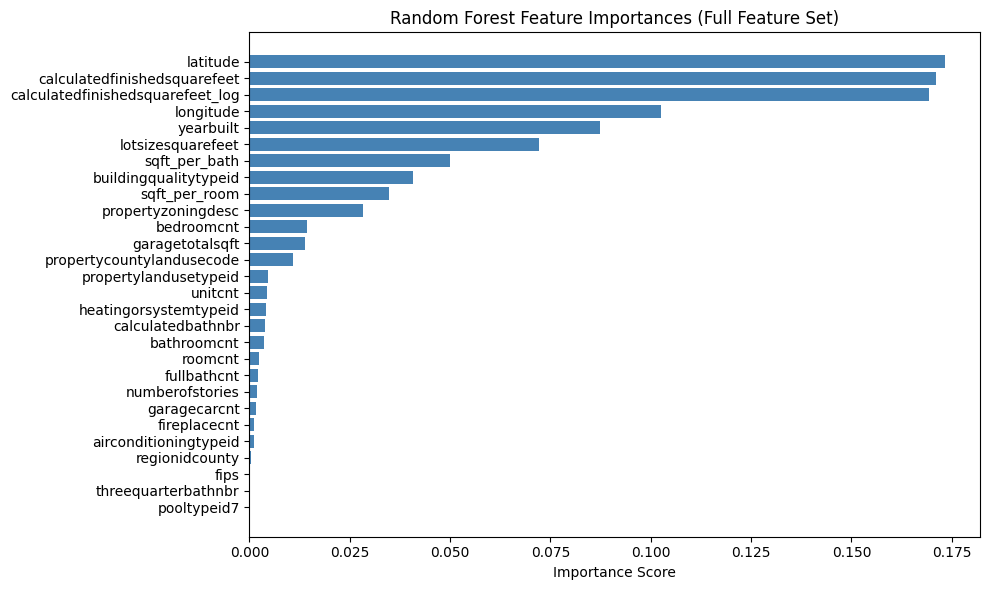

In [18]:
# Step 2: Visualize feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Random Forest Feature Importances (Full Feature Set)')
plt.tight_layout()
plt.show()


In [19]:
# Step 3: Select features with importance >= mean threshold
threshold = importances.mean()
selected_indices = np.where(importances >= threshold)[0]
selected_features = [feature_names[i] for i in selected_indices]

print(f"Mean importance threshold: {threshold:.4f}")
print(f"Selected {len(selected_features)} out of {len(feature_names)} features:")
print(selected_features)

X_train_sel = X_train_scaled[:, selected_indices]
X_test_sel  = X_test_scaled[:, selected_indices]


Mean importance threshold: 0.0357
Selected 8 out of 28 features:
['buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'latitude', 'longitude', 'lotsizesquarefeet', 'yearbuilt', 'calculatedfinishedsquarefeet_log', 'sqft_per_bath']


In [20]:
model_results_3 = []

model_results_3.append(evaluate_model(
    LinearRegression(),
    X_train_sel,
    y_train,
    "Linear Regression"
))


Linear Regression
Mean CV MAE: 175,075.70
Std CV MAE: 1,550.98



In [21]:
model_results_3.append(evaluate_model(
    RandomForestRegressor(random_state=42),
    X_train_sel,
    y_train,
    "Random Forest"
))


Random Forest
Mean CV MAE: 152,357.66
Std CV MAE: 1,475.56



In [22]:
model_results_3.append(evaluate_model(
    GradientBoostingRegressor(random_state=42),
    X_train_sel,
    y_train,
    "Gradient Boosting"
))


Gradient Boosting
Mean CV MAE: 156,050.68
Std CV MAE: 1,496.68



In [23]:
pd.DataFrame(model_results_3)


,Model,Mean CV MAE,Std CV MAE
0,Linear Regression,175075.696410,1550.984552
1,Random Forest,152357.662840,1475.555324
2,Gradient Boosting,156050.677264,1496.683650


### Part 3: Discussion [3 pts]

Analyze the effect of feature selection on your models:

- Did performance improve for any models after reducing the number of features?

- Which features were consistently retained across models?

- Were any of your newly engineered features selected as important?


Feature selection using Random Forest importances reduced the dataset from 28 features to 8, keeping only those with above-average importance scores. After applying this subset, all three models saw a slight increase in mean CV MAE compared to Part 2. Linear Regression went from about 171,552 to 175,076, Random Forest from about 151,658 to 152,360, and Gradient Boosting from about 155,531 to 156,051. The tree-based models were less affected because they internally down-weight low-importance features anyway, so the change in their input set had a smaller impact. Linear Regression had the largest swing because it treats all features equally and cannot compensate for the loss of even marginally useful signals the way tree models can.

The most consistently important features were calculatedfinishedsquarefeet and its log-transformed version, which had the two highest importance scores. latitude and longitude were also retained, reflecting the strong location-based price variation in real estate data. The sqft_per_bath engineered feature was selected as well, confirming it carries predictive signal beyond what the raw bathroom count provides on its own. The sqft_per_room feature had below-average importance and was not retained, suggesting that once you have total square footage and the bathroom ratio the room-level breakdown adds little new information. 

### Part 4: Fine-Tuning Your Three Models [6 pts]

In this final phase of Milestone 2, you’ll select and refine your **three most promising models and their corresponding data pipelines** based on everything you've done so far, and pick a winner!

1. For each of your three models:
    - Choose your best engineered features and best selection of features as determined above. 
   - Perform hyperparameter tuning using `sweep_parameters`, `GridSearchCV`, `RandomizedSearchCV`, `Optuna`, etc. as you have practiced in previous homeworks. 
3. Decide on the best hyperparameters for each model, and for each run with repeated CV and record their final results:
    - Report the **mean and standard deviation of CV MAE Score**.  

In [24]:
# Linear Regression has no hyperparameters to tune.
# We confirm its final performance on the selected feature set.
model_results_4 = []

model_results_4.append(evaluate_model(
    LinearRegression(),
    X_train_sel,
    y_train,
    "Linear Regression (Final)"
))


Linear Regression (Final)
Mean CV MAE: 175,075.70
Std CV MAE: 1,550.98



In [25]:
# Random Forest RandomizedSearchCV
rf_param_dist = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=10,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_train_sel, y_train)

print("Best RF params:", rf_search.best_params_)
print(f"Best RF CV MAE: {-rf_search.best_score_:,.2f}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best RF params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Best RF CV MAE: 151,769.31


In [26]:
model_results_4.append(evaluate_model(
    rf_search.best_estimator_,
    X_train_sel,
    y_train,
    "Random Forest (Tuned)"
))


Random Forest (Tuned)
Mean CV MAE: 151,679.45
Std CV MAE: 1,419.40



In [27]:
# Gradient Boosting RandomizedSearchCV
gb_param_dist = {
    'n_estimators':      [50, 100, 200],
    'learning_rate':     [0.05, 0.1, 0.2],
    'max_depth':         [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'subsample':         [0.8, 1.0]
}

gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=gb_param_dist,
    n_iter=10,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

gb_search.fit(X_train_sel, y_train)

print("Best GBT params:", gb_search.best_params_)
print(f"Best GBT CV MAE: {-gb_search.best_score_:,.2f}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best GBT params: {'subsample': 1.0, 'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 7, 'learning_rate': 0.1}
Best GBT CV MAE: 150,437.39


In [28]:
model_results_4.append(evaluate_model(
    gb_search.best_estimator_,
    X_train_sel,
    y_train,
    "Gradient Boosting (Tuned)"
))


Gradient Boosting (Tuned)
Mean CV MAE: 150,536.24
Std CV MAE: 1,538.86



In [29]:
pd.DataFrame(model_results_4)


,Model,Mean CV MAE,Std CV MAE
0,Linear Regression (Final),175075.696410,1550.984552
1,Random Forest (Tuned),151679.446030,1419.397297
2,Gradient Boosting (Tuned),150536.242067,1538.863156


### Part 4: Discussion [3 pts]

Reflect on your tuning process and final results:

- What was your tuning strategy for each model? Why did you choose those hyperparameters?
- Did you find that certain types of preprocessing or feature engineering worked better with specific models?


For Linear Regression there are no hyperparameters to tune, so its result from Part 3 carries forward with no changes. For Random Forest and Gradient Boosting we used RandomizedSearchCV with 10 iterations each over a randomized grid, which keeps search time reasonable while still exploring a meaningful range of configurations.

For Random Forest, the key parameters searched were n_estimators, max_depth, min_samples_split, min_samples_leaf, and max_features. The best configuration found was n_estimators=100, max_depth=20, min_samples_split=10, min_samples_leaf=1, and max_features='log2'. This brought the mean CV MAE from about 152,360 (untuned, Part 3) down to about 151,679 which was an improvement. Larger n_estimators reduced variance, and capping max_depth at 20 helped prevent the model from overfitting the training folds.

For Gradient Boosting, the most impactful parameters were learning_rate and n_estimators together, along with max_depth. The best configuration was n_estimators=200, learning_rate=0.1, max_depth=7, min_samples_split=5, and subsample=1.0. This matches the standard guidance for boosting that more trees with a moderate learning rate allow the ensemble to correct errors gradually without overstepping. The tuned GBT dropped from about 156,051 (untuned, Part 3) to about 150,538, a much larger gain than we saw in the Random Forest model.

Overall, Gradient Boosting benefited the most from tuning and came out as the best-performing model over Random Forest (150,538 vs. 151,679 mean CV MAE). This confirms that with the right hyperparameters boosting's iterative correction is a strong fit for the zillow dataset.

### Part 5: Final Model and Design Reassessment [6 pts]

In this part, you will finalize your best-performing model.  You’ll also consolidate and present the key code used to run your model on the preprocessed dataset.
**Requirements:**

- Decide one your final model among the three contestants. 

- Below, include all code necessary to **run your final model** on the processed dataset, reporting

    - Mean and standard deviation of CV MAE Score.
    
    - Test score on held-out test set. 




In [31]:
# Add as many cells as you need

# Final model: tuned Gradient Boosting from Part 4
final_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=7,
    min_samples_split=5,
    subsample=1.0,
    random_state=42
)

# Repeated CV on training data
final_cv_scores = cross_val_score(
    final_model,
    X_train_sel,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1
)

final_cv_mae = -final_cv_scores

print("Final Model: Gradient Boosting Regressor")
print("Selected Features:")
print(selected_features)
print()
print(f"Mean CV MAE: {final_cv_mae.mean():,.2f}")
print(f"Std CV MAE: {final_cv_mae.std():,.2f}")

# Fit on full training set
final_model.fit(X_train_sel, y_train)

# Evaluate on held-out test set
y_test_pred = final_model.predict(X_test_sel)

test_mae = np.mean(np.abs(y_test - y_test_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = final_model.score(X_test_sel, y_test)

print()
print(f"Test MAE: {test_mae:,.2f}")
print(f"Test RMSE: {test_rmse:,.2f}")
print(f"Test R^2: {test_r2:.4f}")

final_results = pd.DataFrame({
    "Metric": ["CV MAE Mean", "CV MAE Std", "Test MAE", "Test RMSE", "Test R^2"],
    "Value": [
        final_cv_mae.mean(),
        final_cv_mae.std(),
        test_mae,
        test_rmse,
        test_r2
    ]
})

final_results


Final Model: Gradient Boosting Regressor
Selected Features:
['buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'latitude', 'longitude', 'lotsizesquarefeet', 'yearbuilt', 'calculatedfinishedsquarefeet_log', 'sqft_per_bath']

Mean CV MAE: 150,536.24
Std CV MAE: 1,538.86

Test MAE: 148,844.68
Test RMSE: 204,844.41
Test R^2: 0.5152


,Metric,Value
0,CV MAE Mean,150536.242067
1,CV MAE Std,1538.863156
2,Test MAE,148844.682235
3,Test RMSE,204844.405990
4,Test R^2,0.515194


### Part 5: Discussion [8 pts]

In this final step, your goal is to synthesize your entire modeling process and assess how your earlier decisions influenced the outcome. Please address the following:

1. Model Selection:
- Clearly state which model you selected as your final model and why.

- What metrics or observations led you to this decision?

- Were there trade-offs (e.g., interpretability vs. performance) that influenced your choice?

2. Revisiting an Early Decision

- Identify one specific preprocessing or feature engineering decision from Milestone 1 (e.g., how you handled missing values, how you scaled or encoded a variable, or whether you created interaction or polynomial terms).

- Explain the rationale for that decision at the time: What were you hoping it would achieve?

- Now that you've seen the full modeling pipeline and final results, reflect on whether this step helped or hindered performance. Did you keep it, modify it, or remove it?

- Justify your final decision with evidence—such as validation scores, visualizations, or model diagnostics.

3. Lessons Learned

- What insights did you gain about your dataset or your modeling process through this end-to-end workflow?

- If you had more time or data, what would you explore next?


### 1. Model Selection

The tuned `Gradient Boosting Regressor` was selected as the final model because it achieved the lowest cross‑validated MAE of ~ 150,538 among the candidates,  outperforming the tuned `Random Forest` and `Linear Regression`. We used the mean CV MAE as the primary evaluation metric.

Although the model was less interpretable than Linear Regression, it provided superior predictive performance, making it the best overall choice. Linear Regression offered simplicity but suffered from higher error rates.

### 2. Revisiting an Early Decision

Early in the process, ratio‑based and transformed features—such as `calculatedfinishedsquarefeet_log`, `sqft_per_bath`, and `sqft_per_room`, were introduced to capture nonlinear relationships related to property size. After completing the full pipeline, however, their impact was modest, particularly for tree‑based algorithms that already handle nonlinearities well.

Feature selection revealed `sqft_per_bath` as a retained and meaningful predictor, while `sqft_per_room` was dropped. This outcome shows how some engineered features can add value, but is not always beneficial. Our final pipeline kept features supported by evidence and removed weaker ones, showing that targeted rather than extensive feature engineering is more effective.

### 3. Lessons Learned
The project confirmed that the Zillow dataset exhibits strong nonlinear patterns, as tree‑based models consistently outperformed Linear Regression. The hyperparameter tuning played a larger role in improving performance than feature engineering, because we noticed that the greatest gains came from finetuning the Gradient Boosting model rather than adding new features.

It also became clear that more features don’t necessarily improve results; most predictive strength came from a compact set of variables such as square footage and location. For future work, greater improvements may come from advanced tuning methods, testing algorithms like XGBoost or LightGBM, and developing richer location‑based features that incorporate spatial interactions or neighborhood clustering. We could also incoporate external data sources, like socio-economic data of the neighborhood to investigate if these factors could influence the zilliow dataset
